In [1]:
import os
import tifffile
import rasterio

import cv2
import numpy as np

import leafmap.leafmap as leafmap
#from samgeo import SamGeo2

import geopandas as gpd
import pickle
from pyproj import Transformer

from utils.raster_tools import Raster_profile #class type for raster profile
import matplotlib.pyplot as plt

### See the overall

In [ ]:
clipped_theos_file = "theos/clipped_IMG_T2V_20250119034323_ORTHO_PMS_32_small.tif"

# m = leafmap.Map(center=[(lat_start + lat_end)/2, (long_start + long_end)/2], zoom=16, height="800px")
m = leafmap.Map(center=[12.908807, 100.922147], zoom=16 , height="800px") 

m.add_basemap("Satellite") 
m.add_raster(clipped_theos_file, layer_name="Theos") 
m

## Read the cliped Google image

In [3]:
theos_Profile = Raster_profile(clipped_theos_file) 

Dataset name: theos/clipped_IMG_T2V_20250119034323_ORTHO_PMS_32_small.tif
File mode: r
Number of bands: 4
Image width: 7001 pixels
Image height: 7053 pixels
Coordinate Reference System (CRS): EPSG:32647
Data shape: (4, 7053, 7001)
Data type: uint16


### Specify the grid's spacing

In [4]:
from pyproj import Transformer
import csv

def setup_polygon(long_start, lat_start, long_end, lat_end, crs_source="EPSG:4326", crs_target="EPSG:32647"): 
    bbox = [long_start, lat_start, long_end, lat_end] 
    coordinates = [
        [bbox[0], bbox[3]],  # Top-left corner (min_lon, max_lat)
        [bbox[2], bbox[3]],  # Top-right corner (max_lon, max_lat)
        [bbox[2], bbox[1]],  # Bottom-right corner (max_lon, min_lat)
        [bbox[0], bbox[1]],  # Bottom-left corner (min_lon, min_lat)
        [bbox[0], bbox[3]]   # Closing the polygon by repeating the first point
        ]

    transformer = Transformer.from_crs(crs_source, crs_target, always_xy=True)
    poly_gons = []
    for coord in coordinates: 
        easting, northing = transformer.transform(coord[0], coord[1])
        poly_gons.append([easting, northing])

    return poly_gons, bbox, coordinates

def save_stats(stats, path_npz, path_csv):
    np.savez(path_npz, **stats)

    with open(path_csv, 'w', newline='') as file:
        writer = csv.writer(file)
        # Write header
        writer.writerow(['Key', 'Value'])
        # Write data line by line
        for key, value in stats.items():
            writer.writerow([key, value])
            
def read_npz(npz_filename):
    read_stats = dict(np.load(npz_filename))

    read_dict = {}
    for key, value in read_stats.items():
        try:
            read_dict[key] = value.item() 
        except:
            read_dict[key] = value

    return read_dict

In [5]:
long_start, lat_start = theos_Profile.get_longlat_from_image_pixels(0, 0, crs_dst="EPSG:4326")

In [6]:
long_end, lat_end = theos_Profile.get_longlat_from_image_pixels(7001, 7053, crs_dst="EPSG:4326")

In [8]:
zoom_level = 18 # Google resolution // the higher zoom level >> higher resolution 
lat_diff   = np.abs(lat_end - lat_start)/10
long_diff  = lat_diff
crs_source = "EPSG:4326" # Google 
crs_target = "EPSG:32647" # Theos

In [15]:
slice_row   = 10
slice_column = 1

slices_path = "ISP0704-Zoom%d" % zoom_level


slice_subpath  = os.path.join(slices_path, "%000d-%000d" % (slice_row, slice_column))
slice_google_filename = os.path.join(slice_subpath, "google.tif") 
warped_slice_google_filename = os.path.join(slice_subpath, "warped_google.tif") 
slice_theos_filename  = os.path.join(slice_subpath, "theos.tif") 
npz_filename  = os.path.join(slice_subpath, "stats.npz") 
csv_filename = os.path.join(slice_subpath, "stats.csv") 

os.makedirs(slices_path, exist_ok=True)
os.makedirs(slice_subpath, exist_ok=True)


long_start_temp = long_start  + (slice_column-1)*long_diff.item()  
# lat_start_temp  = lat_start  - (slice_no)*lat_diff.item()
lat_start_temp  = lat_start - (slice_row-1)*lat_diff.item()

long_end_temp = long_start + (slice_column)*long_diff.item()  
#lat_end_temp  = lat_start  - (slice_no+1)*lat_diff.item()
lat_end_temp  = lat_start  -  (slice_row)*lat_diff.item()


print("Slice no. %000d-%000d" % (slice_row, slice_column)) 
print("Start: LON: %f LAT: %f" % (long_start_temp, lat_start_temp)) 
print("End  : LON: %f LAT: %f" % (long_end_temp, lat_end_temp)) 

poly_gons, bbox, coordinates = setup_polygon(long_start_temp, lat_start_temp, long_end_temp, lat_end_temp, crs_source=crs_source, crs_target=crs_target)

leafmap.map_tiles_to_geotiff(output=slice_google_filename, bbox=bbox, zoom=zoom_level, source="Satellite", overwrite=True)
leafmap.clip_image(clipped_theos_file, poly_gons, slice_theos_filename)


stats = {"slice_row": slice_row, 
        "slice_column": slice_column,
        "slice_theos_filename": slice_theos_filename,
        "slice_google_filename": slice_google_filename,  
        "long_start_temp": long_start_temp,
        "lat_start_temp": lat_start_temp,
        "long_end_temp": long_end_temp,
        "lat_end_temp": lat_end_temp,
        "poly_gons": poly_gons,
        "bbox":bbox,
        "coordinates": coordinates,
        "crs_source": crs_source,
        "crs_target": crs_target,
        "long_diff": long_diff,
        "lat_diff": lat_diff}

save_stats(stats, npz_filename, csv_filename)

Slice no. 10-1
Start: LON: 100.886455 LAT: 12.913831
End  : LON: 100.889643 LAT: 12.910644
Downloaded image 1/12
Downloaded image 2/12
Downloaded image 3/12
Downloaded image 4/12
Downloaded image 5/12
Downloaded image 6/12
Downloaded image 7/12
Downloaded image 8/12
Downloaded image 9/12
Downloaded image 10/12
Downloaded image 11/12
Downloaded image 12/12
Saving GeoTIFF. Please wait...


Reading input: c:\Users\Msi Bravo\CAPSTONE_THEOS\geo\GeoAnnotation\ISP0704-Zoom18\10-1\theos.tif

Adding overviews...


Image saved to ISP0704-Zoom18\10-1\google.tif


Updating dataset tags...
Writing output to: c:\Users\Msi Bravo\CAPSTONE_THEOS\geo\GeoAnnotation\ISP0704-Zoom18\10-1\theos.tif


## Test sliced data

### Stats reading

In [16]:
read_dict = read_npz(npz_filename)
read_dict

{'slice_row': 10,
 'slice_column': 1,
 'slice_theos_filename': 'ISP0704-Zoom18\\10-1\\theos.tif',
 'slice_google_filename': 'ISP0704-Zoom18\\10-1\\google.tif',
 'long_start_temp': 100.88645527094697,
 'lat_start_temp': 12.913831456474659,
 'long_end_temp': 100.88964262019294,
 'lat_end_temp': 12.910644107228677,
 'poly_gons': array([[ 704676.2333868 , 1428007.26879838],
        [ 705022.16730998, 1428009.81672962],
        [ 705019.56741495, 1428362.4650912 ],
        [ 704673.63788468, 1428359.91657399],
        [ 704676.2333868 , 1428007.26879838]]),
 'bbox': array([100.88645527,  12.91383146, 100.88964262,  12.91064411]),
 'coordinates': array([[100.88645527,  12.91064411],
        [100.88964262,  12.91064411],
        [100.88964262,  12.91383146],
        [100.88645527,  12.91383146],
        [100.88645527,  12.91064411]]),
 'crs_source': 'EPSG:4326',
 'crs_target': 'EPSG:32647',
 'long_diff': 0.003187349245982141,
 'lat_diff': 0.003187349245982141}

### Map reading

In [17]:
m = leafmap.Map()    
slice_google_filename_prev = 'ISP0704-Zoom18/1-1/google.tif'
slice_theos_filename_prev = 'ISP0704-Zoom18/1-1/theos.tif'
m.add_raster(slice_google_filename_prev, layer_name="Google-prev")
m.add_raster(slice_theos_filename_prev, layer_name="Theos-prev") 
m.add_raster(slice_google_filename, layer_name="Google")
m.add_raster(slice_theos_filename, layer_name="Theos") 
m

Map(center=[12.912239, 100.88804999999999], controls=(ZoomControl(options=['position', 'zoom_in_text', 'zoom_i…

### Test warping

In [18]:
from plantcv import plantcv as pcv
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import numpy as np
import tifffile

from utils.tools import get_raster_data, image_enhancement, save_raster_and_write_meta

In [19]:
# slice_no   = 0

slices_path     = "ISP0704-Zoom%d" % zoom_level
slice_subpath  = os.path.join(slices_path, "%000d-%000d" % (slice_row, slice_column))

slice_google_filename = os.path.join(slice_subpath, "google.tif") 
warped_slice_google_filename = os.path.join(slice_subpath, "warped_google.tif") 
slice_theos_filename  = os.path.join(slice_subpath, "theos.tif")  
path_warp_npz  = os.path.join(slice_subpath, "warp_stats.npz")  
path_warp_csv  = os.path.join(slice_subpath, "warp_stats.csv")   


In [20]:
imgA, _ = get_raster_data(slice_google_filename) 
imgA = np.transpose(imgA, (1, 2, 0))  # Convert from (bands, height, width) to (height, width, bands)
 
imgB, _  = get_raster_data(slice_theos_filename) 
imgB = np.transpose(imgB, (1, 2, 0))  # Convert from (bands, height, width) to (height, width, bands)
imgB = imgB[:,:,:3]
imgB = image_enhancement(imgB) #แก้ exposure intensity (ไว้เพิ่มใน report)

Dataset name: ISP0704-Zoom18\10-1\google.tif
File mode: r
Number of bands: 3
Image width: 594 pixels
Image height: 610 pixels
Coordinate Reference System (CRS): EPSG:3857
Data shape: (3, 610, 594)
Data type: uint8
Dataset name: ISP0704-Zoom18\10-1\theos.tif
File mode: r
Number of bands: 4
Image width: 698 pixels
Image height: 710 pixels
Coordinate Reference System (CRS): EPSG:32647
Data shape: (4, 710, 698)
Data type: uint16


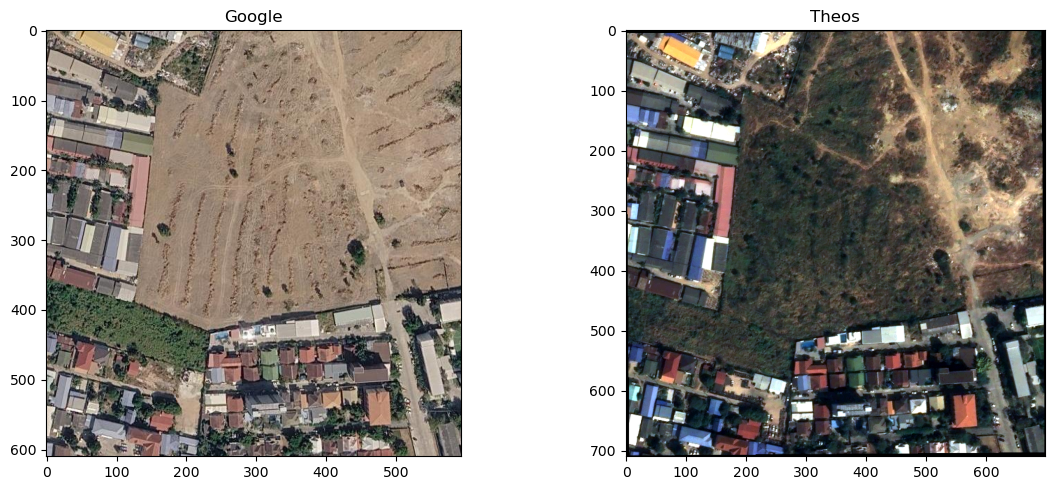

In [21]:
from utils.interactive_tools import Find_correspondences

%matplotlib widget
marker_AB = Find_correspondences(imgA, imgB, figsize=(12, 5))

In [22]:
import cv2

point_src  = np.array(marker_AB.points[0])
point_dst  = np.array(marker_AB.points[1])

Homography, status = cv2.findHomography(point_src, point_dst) 

In [23]:
target_size = (imgB.shape[1], imgB.shape[0])
im_dst = cv2.warpPerspective(imgA, Homography, target_size) 

In [24]:
warp_stats = {
    "point_src": point_src,
    "point_dst": point_dst,
    "Homography": Homography,
    "target_size": target_size, 
    "src_img_filename": slice_google_filename,
    "dst_img_filename": slice_theos_filename,
    "result_image_filename": warped_slice_google_filename
}

In [25]:
save_stats(warp_stats, path_warp_npz, path_warp_csv)

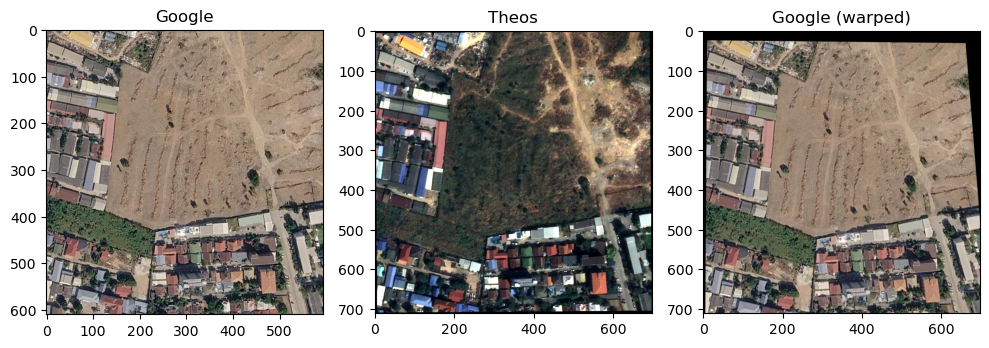

In [26]:
fig, axs = plt.subplots(1, 3, figsize=(10,5)) 
axs[0].imshow(imgA[:,:,0:3])  # Display the first three channels (RGB) of the clipped image
axs[0].set_title('Google') # Set a title for the first subplot 

axs[1].imshow(imgB[:,:,0:3])  # Display the first three channels (RGB) of the clipped satellite image
axs[1].set_title('Theos') # Set a title for the second subplot 

axs[2].imshow(im_dst[:,:,0:3])  # Display the first three channels (RGB) of the clipped satellite image
axs[2].set_title('Google (warped)') # Set a title for the second subplot 
 
fig.tight_layout()

In [27]:
im_dst_4D = np.zeros((imgB.shape[0], imgB.shape[1], 4)) 
im_dst_4D[:,:,:3] = im_dst 
im_dst_4D[:,:, 3] = 254
im_dst_4D = im_dst_4D.transpose(2, 0, 1)
im_dst_4D = im_dst_4D.astype(np.uint8)

destination_tif = warped_slice_google_filename
meta_source_tif = slice_theos_filename
save_raster_and_write_meta(im_dst_4D , destination_tif, meta_source_tif)

Modified image saved to : ISP0704-Zoom18\10-1\warped_google.tif


In [28]:
import leafmap.leafmap as leafmap
m = leafmap.Map()
m.add_raster(slice_google_filename, layer_name="Google") 
m.add_raster(slice_theos_filename, layer_name="theos") 
m.add_raster(warped_slice_google_filename, layer_name="Google (warped)")  
m

Map(center=[12.912239, 100.88804999999999], controls=(ZoomControl(options=['position', 'zoom_in_text', 'zoom_i…

### Test SamGeo2

In [29]:
from samgeo import SamGeo2 

In [30]:
sam = SamGeo2(
    model_id="sam2-hiera-large", 
    automatic=False
)

In [31]:
# slice_no   = 0

slices_path     = "ISP0704-Zoom%d" % zoom_level
slice_subpath   = os.path.join(slices_path, "%000d-%000d" % (slice_row, slice_column)) 
warped_slice_google_filename = os.path.join(slice_subpath, "warped_google.tif")  
target_dir      = os.path.join(slice_subpath, "samgeo2mask")  
os.makedirs(target_dir, exist_ok=True)


In [32]:
print("PLEASE SAVE THE MASK under Folder: %s" % target_dir)

PLEASE SAVE THE MASK under Folder: ISP0704-Zoom18\10-1\samgeo2mask


In [33]:
sam.set_image(warped_slice_google_filename)
sam.show_map()

Map(center=[12.912239, 100.88804999999999], controls=(ZoomControl(options=['position', 'zoom_in_text', 'zoom_i…

In [34]:
mask_filename = os.path.join(slice_subpath,"samgeo2mask", "masks.tif") 

In [35]:
import leafmap.leafmap as leafmap
m = leafmap.Map() 
m.add_raster(slice_theos_filename, layer_name="theos") 
m.add_raster(warped_slice_google_filename, layer_name="Google (warped)")  
m.add_raster(mask_filename, cmap="jet", layer_name="Mask (warped)")  
m

Map(center=[12.912239, 100.88804999999999], controls=(ZoomControl(options=['position', 'zoom_in_text', 'zoom_i…

## Mask improvement

In [36]:
from utils.mask_tools import Mask_profile

from plantcv import plantcv as pcv
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import numpy as np
import tifffile

from utils.tools import get_raster_data, image_enhancement, save_raster_and_write_meta

In [37]:
#slice_no =0

mask_filename = os.path.join(slice_subpath, "samgeo2mask", "masks.tif") 
center_geojson = os.path.join(slice_subpath, "samgeo2mask", "masks_fg_markers.geojson")  
warped_slice_google_filename = os.path.join(slice_subpath, "warped_google.tif") 
sat_image, _ = get_raster_data(warped_slice_google_filename)

Dataset name: ISP0704-Zoom18\10-1\warped_google.tif
File mode: r
Number of bands: 4
Image width: 698 pixels
Image height: 710 pixels
Coordinate Reference System (CRS): EPSG:32647
Data shape: (4, 710, 698)
Data type: uint8


Dataset name: ISP0704-Zoom18\10-1\samgeo2mask\masks.tif
File mode: r
Number of bands: 1
Image width: 698 pixels
Image height: 710 pixels
Coordinate Reference System (CRS): EPSG:32647
Data shape: (1, 710, 698)
Data type: int32


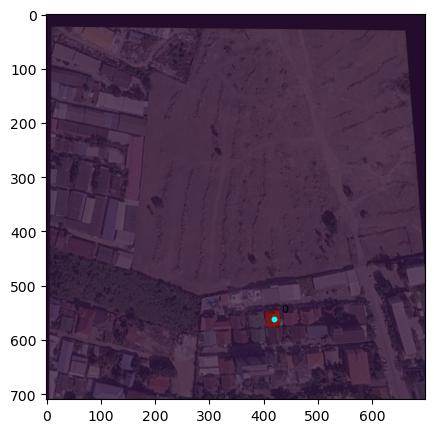

In [38]:
Mask_obj = Mask_profile(mask_filename, center_geojson_file=center_geojson, center_geojson_crs="EPSG:4326") 
Mask_obj.show_mask_order(figsize=(10, 5), fontsize=8, alpha=0.75, satellite_image=sat_image)

In [39]:
sat_image.shape
sat_image = sat_image.transpose(1,2,0)[:,:,:3]

In [40]:
gray_bf_operation = Mask_obj.mask.copy()

for manual_index in range(Mask_obj.mask.max()):

    
    gray_bf = Mask_obj.get_a_binary_mask(manual_index)

    record_af_list = []
    gray_af, record_af = Mask_obj.filling_holes(1*gray_bf)
    record_af_list.append(record_af)
    gray_af, record_af = Mask_obj.erosion(gray_af.astype(np.uint8), kernel_size=3) # ลองเพิ่ม erosion ดูว่าช่วยลด noise ได้ไหม
    record_af_list.append(record_af)
    gray_af, record_af = Mask_obj.dilation(gray_af.astype(np.uint8), kernel_size=17)
    record_af_list.append(record_af)

    mask_2D = Mask_obj.update_a_binary_mask(gray_af, manual_index, record_af_list) 

    # fig, axs = plt.subplots(1, 2, figsize=(10, 3))

    # axs[0].imshow(sat_image)
    # axs[0].imshow(gray_bf, cmap='Oranges', alpha=0.45)
    # axs[0].set_title("Mask id %d before [top]" % manual_index)
    

    # axs[1].imshow(sat_image)
    # axs[1].imshow(gray_af, cmap='Oranges', alpha=0.45)
    # axs[1].set_title("Mask id %d after [top]" % manual_index) 

    # plt.tight_layout() 

Text(0.5, 1.0, 'after')

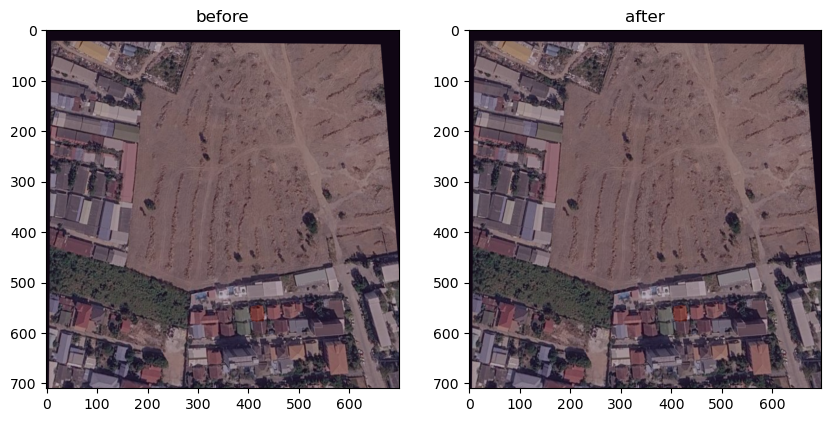

In [41]:
fig, axs = plt.subplots(1, 2, figsize=(10, 12))
axs[0].imshow(sat_image)
axs[0].imshow(gray_bf_operation, cmap='turbo', alpha=0.35) 
axs[0].set_title("before")

axs[1].imshow(sat_image)
axs[1].imshow(mask_2D, cmap='turbo', alpha=0.35) 
axs[1].set_title("after")

In [42]:
edited_mask_filename = os.path.join(slice_subpath,"samgeo2mask", "masks_edited.tif") 
meta_mask_filename   = os.path.join(slice_subpath, "samgeo2mask", "masks.tif") 
mask_2D              = mask_2D.reshape(1, mask_2D.shape[0], mask_2D.shape[1])
save_raster_and_write_meta(mask_2D, edited_mask_filename, meta_mask_filename)

Modified image saved to : ISP0704-Zoom18\10-1\samgeo2mask\masks_edited.tif


In [43]:
m = leafmap.Map()
m.add_raster(warped_slice_google_filename, layer_name="Image") 
m.add_circle_markers_from_xy(center_geojson, radius=3, color="red", fill_color="yellow", fill_opacity=0.8
) 
m.add_raster(mask_filename, cmap="jet", layer_name="Building masks (before)") 
m.add_raster(edited_mask_filename, cmap="jet", layer_name="Building masks (after)") 
m

Map(center=[12.912239, 100.88804999999999], controls=(ZoomControl(options=['position', 'zoom_in_text', 'zoom_i…

In [44]:
bb_filename = os.path.join(slice_subpath, "samgeo2mask", "boundbox.geojson") 
 
gdf = Mask_obj.make_boundboxes()
gdf.to_file(bb_filename, driver='GeoJSON') 

In [45]:
m = leafmap.Map()
m.add_raster(warped_slice_google_filename, layer_name="Image") 
m.add_circle_markers_from_xy(center_geojson, radius=3, color="red", fill_color="yellow", fill_opacity=0.8
)  
m.add_raster(edited_mask_filename, cmap="jet", layer_name="Building masks (after)")  
m.add_vector(bb_filename, layer_name="Bounding Boxes")
m

Map(center=[12.912239, 100.88804999999999], controls=(ZoomControl(options=['position', 'zoom_in_text', 'zoom_i…